[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lalvim/DataMining/blob/main/notebooks/unidade_05/05_02_classificadores_bayesianos_e_knn.ipynb)

# Unidade V — Classificação e Regressão

## Classificadores bayesianos e k-NN

**Carga estimada:** 3 horas  
**Pré-requisitos:** probabilidades condicionais, noções de distância e processo de classificação.

> **Pergunta norteadora:** como classificar um novo objeto usando evidências probabilísticas ou exemplos semelhantes?

Este notebook apresenta a intuição de dois métodos do capítulo 6 de Han, Pei e Tong. O objetivo é compreender como cada método produz uma decisão, e não aprofundar demonstrações estatísticas ou otimização de hiperparâmetros.

## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- interpretar probabilidade prévia, verossimilhança e probabilidade posterior;
- explicar a suposição “ingênua” de independência condicional do Naive Bayes;
- classificar manualmente um caso categórico com suavização de Laplace;
- explicar o k-NN como votação entre exemplos próximos;
- calcular e interpretar distâncias de vizinhos;
- demonstrar por que a escala dos atributos altera a vizinhança;
- relacionar a escolha de $k$ à sensibilidade local e à suavização;
- comparar as perguntas, vantagens e limitações dos dois métodos.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

## 1. Dois modos de usar os exemplos históricos

| Método | Intuição da decisão | O que é guardado ou estimado |
|---|---|---|
| Naive Bayes | combina evidências e escolhe a classe com maior probabilidade posterior | frequências ou distribuições por classe |
| k-NN | procura os $k$ exemplos mais próximos e segue a votação local | os próprios exemplos de treino |

O Naive Bayes é um aprendiz **antecipado** (*eager*): resume os dados durante o treinamento. O k-NN é um aprendiz **preguiçoso** (*lazy*): armazena exemplos e deixa a maior parte do trabalho para o momento da previsão.

Nenhuma dessas descrições implica que um método seja sempre superior. A adequação depende da representação dos atributos, da quantidade de dados, do custo de previsão e do tipo de padrão presente.

## 2. Naive Bayes: atualizar uma crença com evidências

Considere uma classe $C$ e um objeto descrito por atributos $mathbf{x}$. O teorema de Bayes escreve:

$$
P(C\mid\mathbf{x})
=
\frac{P(\mathbf{x}\mid C)P(C)}{P(\mathbf{x})}.
$$

- $P(C)$ é a **probabilidade prévia**: frequência da classe antes de observar o novo objeto;
- $P(\mathbf{x}\mid C)$ é a **verossimilhança**: compatibilidade dos atributos observados com a classe;
- $P(C\mid\mathbf{x})$ é a **probabilidade posterior**: crença atualizada depois das evidências;
- $P(\mathbf{x})$ é comum a todas as classes do mesmo objeto.

Para escolher entre classes, basta comparar os numeradores:

$$
\operatorname{escore}(C)=P(C)P(\mathbf{x}\mid C).
$$

A classe com maior escore terá também a maior posterior.

### Por que o método é chamado de “ingênuo”?

Se $mathbf{x}=(x_1,x_2,\ldots,x_p)$, o Naive Bayes simplifica a verossimilhança:

$$
P(\mathbf{x}\mid C)
\approx
\prod_{j=1}^{p}P(x_j\mid C).
$$

Ele trata os atributos como **condicionalmente independentes dentro de cada classe**. Isso permite estimar várias probabilidades pequenas em vez de uma combinação para cada perfil possível.

A suposição frequentemente é imperfeita. Por exemplo, “muitos chamados” e “texto urgente” podem continuar relacionados mesmo entre chamados prioritários. Nessa situação, as duas evidências podem ser contadas como se trouxessem informações separadas. Ainda assim, o método costuma ser uma referência rápida e útil, especialmente em dados de texto e atributos de contagem.

## 3. Exemplo manual: prioridade de chamados

A tabela sintética contém 12 chamados já classificados. Usaremos três atributos categóricos para decidir se um novo chamado deve ser tratado como prioritário.

In [2]:
chamados = pd.DataFrame({
    "canal": [
        "app", "app", "web", "app", "web", "app",
        "web", "web", "app", "web", "app", "web",
    ],
    "texto_urgente": [
        "sim", "sim", "sim", "nao", "sim", "sim",
        "nao", "nao", "nao", "sim", "nao", "nao",
    ],
    "cliente_premium": [
        "sim", "nao", "sim", "sim", "nao", "sim",
        "nao", "sim", "nao", "nao", "sim", "nao",
    ],
    "prioritaria": [
        "sim", "sim", "sim", "sim", "sim", "sim",
        "nao", "nao", "nao", "nao", "nao", "nao",
    ],
})
chamados

,canal,texto_urgente,cliente_premium,prioritaria
0,app,sim,sim,sim
1,app,sim,nao,sim
2,web,sim,sim,sim
3,app,nao,sim,sim
4,web,sim,nao,sim
5,app,sim,sim,sim
6,web,nao,nao,nao
7,web,nao,sim,nao
8,app,nao,nao,nao
9,web,sim,nao,nao


### Um novo chamado

Classificaremos:

$$
\mathbf{x}=(\text{canal=app},\ \text{texto urgente=sim},\ \text{cliente premium=sim}).
$$

Há seis chamados em cada classe, logo:

$$
P(\text{prioritária=sim})=P(\text{prioritária=não})=\frac{6}{12}=0{,}5.
$$

Usaremos **suavização de Laplace**. Para um atributo com dois valores possíveis, uma contagem $n$ dentro de uma classe com seis casos torna-se

$$
P(x_j\mid C)=\frac{n+1}{6+2}.
$$

Somar 1 evita que uma combinação inteira receba escore zero apenas porque um valor ainda não apareceu em uma classe. O denominador soma 2 porque cada atributo deste exemplo possui duas categorias.

In [3]:
novo_chamado = {
    "canal": "app",
    "texto_urgente": "sim",
    "cliente_premium": "sim",
}
atributos_categoricos = list(novo_chamado)
classes = ["sim", "nao"]
escores = {}

for classe in classes:
    dados_classe = chamados[chamados["prioritaria"] == classe]
    previa = len(dados_classe) / len(chamados)
    fatores = {}
    escore = previa

    for atributo, valor in novo_chamado.items():
        contagem = (dados_classe[atributo] == valor).sum()
        numero_categorias = chamados[atributo].nunique()
        probabilidade = (contagem + 1) / (
            len(dados_classe) + numero_categorias
        )
        fatores[atributo] = probabilidade
        escore *= probabilidade

    escores[classe] = {
        "previa": previa,
        **fatores,
        "escore_nao_normalizado": escore,
    }

tabela_escores = pd.DataFrame(escores).T
soma_escores = tabela_escores["escore_nao_normalizado"].sum()
tabela_escores["posterior_normalizada"] = (
    tabela_escores["escore_nao_normalizado"] / soma_escores
)

assert np.isclose(tabela_escores.loc["sim", "posterior_normalizada"], 0.892857)
tabela_escores.round(4)

,previa,canal,texto_urgente,cliente_premium,escore_nao_normalizado,posterior_normalizada
sim,0.5,0.625,0.75,0.625,0.1465,0.8929
nao,0.5,0.375,0.25,0.375,0.0176,0.1071


### Da conta à decisão

Para a classe prioritária:

$$
0{,}5\times\frac{5}{8}\times\frac{6}{8}\times\frac{5}{8}
=0{,}1465.
$$

Para a classe não prioritária:

$$
0{,}5\times\frac{3}{8}\times\frac{2}{8}\times\frac{3}{8}
=0{,}0176.
$$

Normalizando os dois escores, a posterior da classe prioritária é aproximadamente 0,8929. O método, portanto, prevê **prioritária**.

Esse número depende da base pequena, da suavização e da hipótese de independência. Ele não deve ser lido automaticamente como uma probabilidade perfeitamente calibrada no atendimento real.

## 4. k-NN: decidir por analogia local

No método dos $k$ vizinhos mais próximos (*k-nearest neighbors*, k-NN), um novo objeto é comparado aos exemplos armazenados:

1. calcular a distância entre o novo objeto e cada exemplo;
2. selecionar os $k$ menores valores;
3. realizar uma votação entre as classes desses vizinhos;
4. atribuir a classe majoritária.

Para atributos numéricos, uma escolha comum é a distância Euclidiana:

$$
d(\mathbf{x},\mathbf{z})
=
\sqrt{\sum_{j=1}^{p}(x_j-z_j)^2}.
$$

A proximidade não existe “por si só”: ela depende dos atributos, da escala e da função de distância escolhida.

## 5. Escala pode mudar quem é considerado vizinho

Considere seis clientes descritos por tempo como cliente, em meses, e número de chamados. O novo cliente possui 35 meses e quatro chamados.

O tempo varia por dezenas; os chamados variam de 0 a 5. Sem padronização, um mês de diferença e um chamado de diferença entram numericamente com o mesmo peso, de modo que a amplitude do tempo tende a dominar a distância.

In [4]:
clientes_treino = pd.DataFrame({
    "cliente": list("ABCDEF"),
    "tempo_meses": [5, 10, 20, 30, 40, 50],
    "chamados": [4, 5, 4, 0, 1, 0],
    "cancelou": ["sim", "sim", "sim", "nao", "nao", "nao"],
})
novo_cliente = pd.DataFrame({
    "tempo_meses": [35],
    "chamados": [4],
})

X_clientes = clientes_treino[["tempo_meses", "chamados"]]
escalonador = StandardScaler()
X_padronizado = escalonador.fit_transform(X_clientes)
novo_padronizado = escalonador.transform(novo_cliente)

clientes_treino["distancia_original"] = np.linalg.norm(
    X_clientes.to_numpy() - novo_cliente.to_numpy(),
    axis=1,
)
clientes_treino["distancia_padronizada"] = np.linalg.norm(
    X_padronizado - novo_padronizado,
    axis=1,
)

vizinhos_original = clientes_treino.nsmallest(3, "distancia_original")
vizinhos_padronizados = clientes_treino.nsmallest(
    3, "distancia_padronizada"
)

display(clientes_treino.round(3))
display(
    pd.DataFrame({
        "representacao": ["original", "padronizada"],
        "tres_vizinhos": [
            ", ".join(vizinhos_original["cliente"]),
            ", ".join(vizinhos_padronizados["cliente"]),
        ],
        "votacao": [
            vizinhos_original["cancelou"].mode().iloc[0],
            vizinhos_padronizados["cancelou"].mode().iloc[0],
        ],
    })
)

,cliente,tempo_meses,chamados,cancelou,distancia_original,distancia_padronizada
0,A,5,4,sim,30.000,1.884
1,B,10,5,sim,25.020,1.644
2,C,20,4,sim,15.000,0.942
3,D,30,0,nao,6.403,1.972
4,E,40,1,nao,5.831,1.493
5,F,50,0,nao,15.524,2.163


,representacao,tres_vizinhos,votacao
0,original,"E, D, C",nao
1,padronizada,"C, E, B",sim


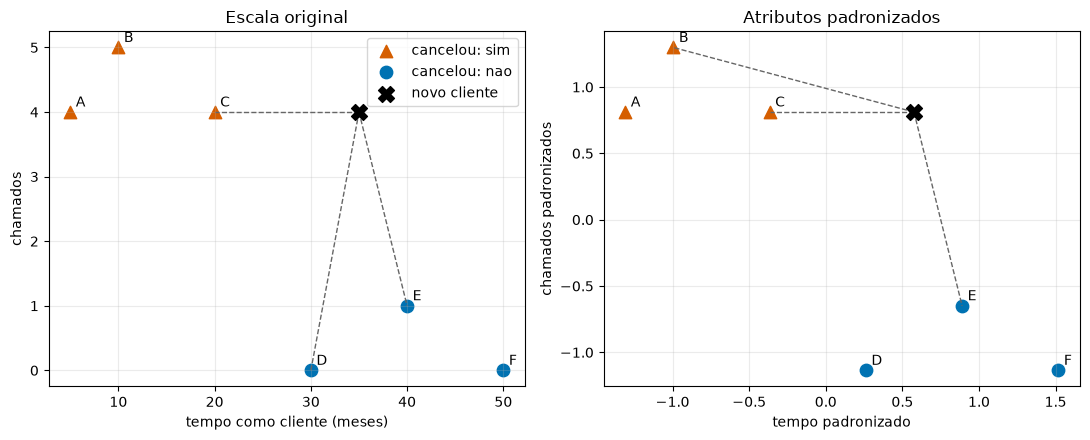

In [5]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.5))

configuracoes = [
    (
        eixos[0],
        X_clientes.to_numpy(),
        novo_cliente.to_numpy()[0],
        vizinhos_original.index,
        "Escala original",
        "tempo como cliente (meses)",
        "chamados",
    ),
    (
        eixos[1],
        X_padronizado,
        novo_padronizado[0],
        vizinhos_padronizados.index,
        "Atributos padronizados",
        "tempo padronizado",
        "chamados padronizados",
    ),
]

for eixo, pontos, consulta, indices, titulo, rotulo_x, rotulo_y in configuracoes:
    for classe, marcador, cor in [
        ("sim", "^", "#D55E00"),
        ("nao", "o", "#0072B2"),
    ]:
        mascara = clientes_treino["cancelou"].eq(classe).to_numpy()
        eixo.scatter(
            pontos[mascara, 0],
            pontos[mascara, 1],
            marker=marcador,
            color=cor,
            s=80,
            label=f"cancelou: {classe}",
        )

    eixo.scatter(
        consulta[0],
        consulta[1],
        marker="X",
        color="#000000",
        s=130,
        label="novo cliente",
        zorder=4,
    )

    for indice in indices:
        eixo.plot(
            [consulta[0], pontos[indice, 0]],
            [consulta[1], pontos[indice, 1]],
            "--",
            color="#666666",
            linewidth=1,
        )

    for indice, identificador in enumerate(clientes_treino["cliente"]):
        eixo.annotate(
            identificador,
            (pontos[indice, 0], pontos[indice, 1]),
            xytext=(4, 4),
            textcoords="offset points",
        )

    eixo.set(title=titulo, xlabel=rotulo_x, ylabel=rotulo_y)
    eixo.grid(alpha=0.25)

eixos[0].legend()
plt.tight_layout()
plt.show()

### O que mudou?

Na escala original, os vizinhos mais próximos são determinados principalmente pelo tempo como cliente. Depois da padronização, diferenças em tempo e chamados passam a ser medidas em unidades comparáveis.

A transformação muda os três vizinhos e pode mudar a votação. Isso não significa que padronizar seja sempre suficiente: atribuir o mesmo peso aos atributos também é uma escolha. Conhecimento do domínio pode indicar que um deles deve pesar mais, que outra distância é apropriada ou que um atributo não deveria ser usado.

## 6. O papel de $k$

- **$k$ pequeno:** decisão muito local; acompanha fronteiras detalhadas, mas é sensível a ruído e casos atípicos.
- **$k$ maior:** votação mais estável; suaviza irregularidades, mas pode apagar grupos pequenos.
- **$k$ grande demais:** aproxima a decisão da classe majoritária da base.

A escolha não deve usar o conjunto de teste final. Em uma análise completa, ela é feita com uma partição de validação ou validação cruzada dentro dos dados de treino. Aqui, observaremos apenas como a previsão do mesmo objeto pode mudar.

In [6]:
resultados_k = []

for representacao, X_usado, consulta in [
    ("original", X_clientes.to_numpy(), novo_cliente.to_numpy()),
    ("padronizada", X_padronizado, novo_padronizado),
]:
    for k in [1, 3, 5]:
        modelo_knn = KNeighborsClassifier(n_neighbors=k)
        modelo_knn.fit(X_usado, clientes_treino["cancelou"])
        resultados_k.append({
            "representacao": representacao,
            "k": k,
            "previsao": modelo_knn.predict(consulta)[0],
        })

pd.DataFrame(resultados_k)

,representacao,k,previsao
0,original,1,nao
1,original,3,nao
2,original,5,nao
3,padronizada,1,sim
4,padronizada,3,sim
5,padronizada,5,sim


## 7. Quando cada método faz sentido?

| Aspecto | Naive Bayes | k-NN |
|---|---|---|
| Pergunta intuitiva | qual classe torna estas evidências mais prováveis? | quais exemplos conhecidos mais se parecem com este caso? |
| Treinamento | estima probabilidades por classe | principalmente armazena exemplos |
| Previsão | geralmente rápida | pode ser custosa em bases grandes |
| Preparação crítica | representação e estimativas de probabilidade | escala, distância, atributos e $k$ |
| Força didática | explicita contribuição probabilística das evidências | permite inspecionar casos próximos |
| Limitação central | independência condicional pode ser irreal | vizinhança perde significado com ruído ou muitas dimensões |

Na mineração de dados, a pergunta mais útil não é “qual algoritmo vence sempre?”, mas “qual representação e qual hipótese combinam com este problema?”. Ambos devem ser avaliados no mesmo conjunto de teste e comparados com um *baseline*.

## Atividades

> **U05-NB02-V01 — Verifique seu entendimento:** por que dois atributos muito correlacionados podem fazer o Naive Bayes tratar uma evidência como se aparecesse duas vezes? Explique por que isso não torna necessariamente todas as classificações incorretas.

> **U05-NB02-E01 — Exercício:** usando a tabela de chamados e suavização de Laplace, classifique o caso $\mathbf{x}=(\text{web},\ \text{não urgente},\ \text{não premium})$. Calcule os dois escores não normalizados, as posteriores normalizadas e apresente a classe escolhida.

> **U05-NB02-E02 — Exercício:** identifique, nas saídas do k-NN, os três vizinhos do novo cliente antes e depois da padronização e a classe prevista em cada representação. Explique numericamente por que a vizinhança mudou.

> **U05-NB02-E03 — Decisão de método:** para classificar rapidamente milhares de documentos representados por ocorrências de palavras, qual método deste notebook seria uma primeira referência plausível? Para justificar uma decisão individual por casos semelhantes, qual seria mais natural? Apresente uma limitação de cada escolha.

## Síntese

- O Naive Bayes combina uma probabilidade prévia com evidências condicionais.
- A independência condicional simplifica o cálculo, mas pode contar evidências relacionadas como separadas.
- A suavização de Laplace impede que uma frequência não observada anule todo o produto.
- O k-NN decide por votação local e depende da representação da proximidade.
- Escala, atributos, distância e $k$ podem mudar os vizinhos e a previsão.
- Métodos diferentes expressam hipóteses diferentes sobre os padrões dos dados.

## Referências

- HAN, Jiawei; PEI, Jian; TONG, Hanghang. *Data Mining: Concepts and Techniques*. 4. ed. Cambridge: Morgan Kaufmann/Elsevier, 2023. Cap. 6, seções 6.3 e 6.4.
- SCIKIT-LEARN DEVELOPERS. *User Guide: Naive Bayes and nearest neighbors*. Documentação das bibliotecas utilizadas nos exemplos computacionais.